In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage
from scipy.stats import mode

In [2]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [3]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [4]:
def get_canny_edges_auto(grey, sigma=0.33, debug=True, title="Canny Edges (Auto)"):

    # Estimate noise level using median
    v = np.median(grey)

    # Automatic thresholds
    low  = int(max(0, (1.0 - sigma) * v))
    high = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(grey, low, high)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(edges, cmap="gray")
        plt.title(f"{title} (low={low}, high={high})")
        plt.axis("off")

    return edges


Loaded images/easy/29.png   shape=(318, 477, 3)
Loaded images/easy/not_that_easy.jpg   shape=(433, 612, 3)
Loaded images/easy/easy.jpg   shape=(459, 612, 3)
Loaded images/easy/20.png   shape=(630, 1200, 3)
Loaded images/medium/12.png   shape=(1080, 1920, 3)
Loaded images/medium/30.png   shape=(204, 890, 3)
Loaded images/medium/31.png   shape=(827, 1412, 3)
Loaded images/hard/21.png   shape=(733, 1100, 3)
Loaded images/hard/frame600.jpg   shape=(2160, 3840, 3)
Loaded images/hard/frame1.jpg   shape=(2160, 3840, 3)
not_that_easy.jpg from the easy set


(np.float64(-0.5), np.float64(611.5), np.float64(432.5), np.float64(-0.5))

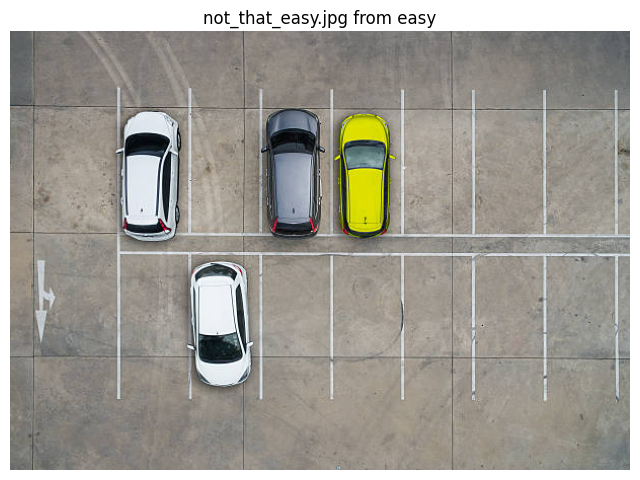

In [222]:


available_images = {
    "easy": [
        "29.png",
        "not_that_easy.jpg",
        "easy.jpg",
        "20.png",
    ],
    "medium": [
        "12.png",
        "30.png",
        "31.png",
    ],
    "hard": [
        "21.png",
        "frame600.jpg",
        "frame1.jpg",
    ]
}

loaded_images = {}

for set_name, file_list in available_images.items():
    loaded_images[set_name] = {}
    
    for fname in file_list:
        path = os.path.join("images", set_name, fname)
        img = cv2.imread(path)

        if img is None:
            print(f"⚠️ Could not load image: {path}")
        else:
            loaded_images[set_name][fname] = img
            print(f"Loaded {path}   shape={img.shape}")

# --- EASY
#(set_name, image_name) = ("easy", "29.png")           # the cartoonish one
(set_name, image_name) = ("easy", "not_that_easy.jpg") # the fake cars ones with the concrete lines.
#(set_name, image_name) = ("easy", "easy.jpg")         # fake empty one with the bits of lines at the bottom
#(set_name, image_name) = ("easy", "20.png")           # The mirror one, real cars

# --- MEDIUM
#(set_name, image_name) = ("medium", "12.png")  # the one with the grass dividers on either side
#(set_name, image_name) = ("medium", "30.png")  # slightly askew lines
#(set_name, image_name) = ("medium", "31.png")  # top and bottom rows.

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg") # dangan large
#(set_name, image_name) = ("hard", "frame1.jpg")   # the dangan crop
#(set_name, image_name) = ("hard", "21.png")       # the rotated image

print(f"{image_name} from the {set_name} set")
img = images[set_name][image_name]
image = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"{image_name} from {set_name}")
plt.axis("off")

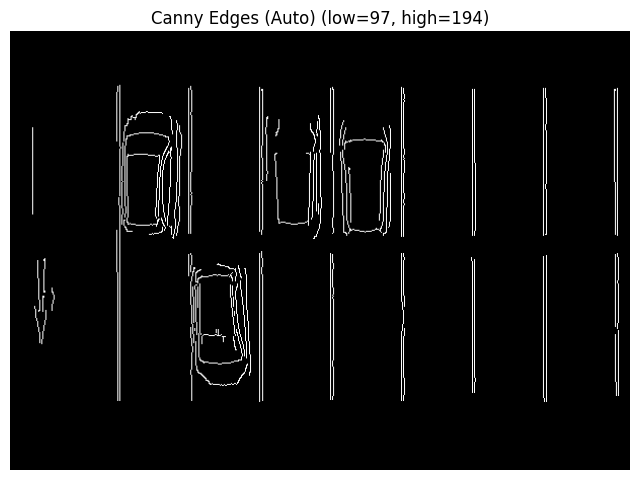

In [223]:
def step_1(img, is_aligned=False):
    img_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_grey, (3,21), 0) 

    canny_output = get_canny_edges_auto(blurred)

    
    return canny_output, img_grey

canny_output, grey = step_1(image)

In [224]:
def cluster_vertical_lines(lines, distance_thresh=20):
    """
    Takes Hough lines and merges vertical-ish lines into averaged lines.
    distance_thresh: max |rho difference| allowed in the same cluster.
    Preserves the actual slanted angle instead of forcing theta = 0.
    """
    vertical_rhos = []
    vertical_thetas = []

    # Extract vertical-ish lines
    for line in lines:
        rho, theta = line

        # Allow angles within ±20° of vertical
        if theta < np.deg2rad(50) or theta > np.deg2rad(160):
            vertical_rhos.append(rho)
            vertical_thetas.append(theta)

    if not vertical_rhos:
        return []

    # Sort by rho
    idx = np.argsort(vertical_rhos)
    rhos_sorted = np.array(vertical_rhos)[idx]
    thetas_sorted = np.array(vertical_thetas)[idx]

    clusters = []
    current_rhos = [rhos_sorted[0]]
    current_thetas = [thetas_sorted[0]]

    for r, t in zip(rhos_sorted[1:], thetas_sorted[1:]):
        if abs(r - current_rhos[-1]) < distance_thresh:
            current_rhos.append(r)
            current_thetas.append(t)
        else:
            clusters.append((current_rhos, current_thetas))
            current_rhos = [r]
            current_thetas = [t]

    clusters.append((current_rhos, current_thetas))

    # Average lines in each cluster
    merged = []
    for rhos, thetas in clusters:
        avg_rho = np.mean(rhos)

        # Normalise angles first so they average correctly
        thetas_norm = [normalise_angle(t) for t in thetas]
        avg_theta_norm = np.mean(thetas_norm)

        # Convert back to full range (0 to pi)
        if avg_theta_norm < 0:
            avg_theta = avg_theta_norm + np.pi
        else:
            avg_theta = avg_theta_norm

        merged.append((avg_rho, avg_theta))

    return merged

In [225]:
def normalise_angle(theta):
    # Convert to orientation angle (0–π) but symmetric
    return theta if theta < np.pi/2 else theta - np.pi

In [226]:
def modal_angle(angles, bin_size_deg=2):
    if len(angles) == 0:
        return None

    bin_size = np.deg2rad(bin_size_deg)
    bins = np.arange(-np.pi/2, np.pi/2 + bin_size, bin_size)

    hist, edges = np.histogram(angles, bins=bins)
    idx = np.argmax(hist)

    # modal angle = center of bin
    modal = (edges[idx] + edges[idx + 1]) / 2
    return modal


In [227]:
def filter_by_modal_angle(lines, angle_tolerance_deg=5):
    """
    lines: list of (rho, theta, x1, y1, x2, y2)
    
    Returns:
        filtered_lines: lines whose angle matches the modal cluster
        weighted_mean_angle: weighted average angle (radians),
                             weight = line segment length
    """
    if not lines:
        return [], None

    # Extract normalized angles
    angs = [normalise_angle(theta) for (rho, theta, *_rest) in lines]

    # Find modal orientation
    modal = modal_angle(angs)
    if modal is None:
        return [], None

    tol = np.deg2rad(angle_tolerance_deg)

    # First filter lines based on modal cluster
    filtered = []
    lengths = []
    angles = []

    for (rho, theta, x1, y1, x2, y2) in lines:
        ang = normalise_angle(theta)
        if abs(ang - modal) < tol:
            filtered.append((rho, theta, x1, y1, x2, y2))

            # compute length for weighting
            length = np.hypot(x2 - x1, y2 - y1)
            lengths.append(length)
            angles.append(ang)

    if not filtered:
        return [], None

    # Compute weighted mean angle (circular!)
    # using unit vectors (cos, sin)
    angles = np.array(angles)
    lengths = np.array(lengths)

    mean_cos = np.sum(lengths * np.cos(angles)) / np.sum(lengths)
    mean_sin = np.sum(lengths * np.sin(angles)) / np.sum(lengths)

    weighted_mean_angle = np.arctan2(mean_sin, mean_cos)

    return filtered, weighted_mean_angle


In [228]:
def line_to_rho_theta(x1, y1, x2, y2):
    angle = np.arctan2((y2 - y1), (x2 - x1))
    theta = angle + np.pi/2

    # midpoint of the segment
    x0 = (x1 + x2) / 2
    y0 = (y1 + y2) / 2

    rho = x0 * np.cos(theta) + y0 * np.sin(theta)

    return rho, theta


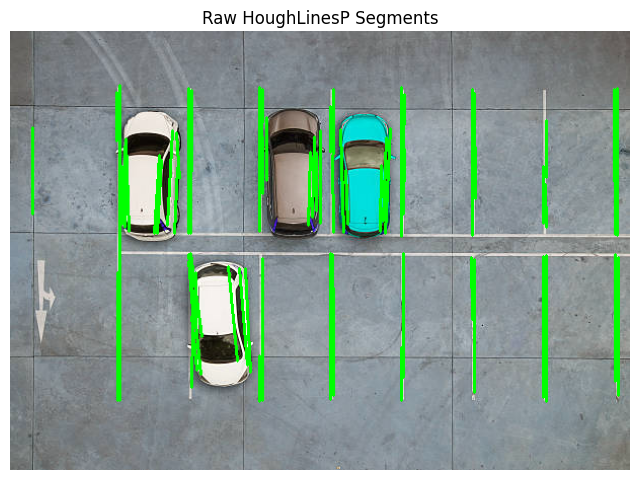

In [229]:
def step_2(canny_input, image, downsample=False, scale=0.5):
    # Copy image for drawing
    if downsample:
        image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        canny_input = cv2.resize(canny_input, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    # Hough transform (probabilistic)
    linesP = cv2.HoughLinesP(
        canny_input,
        rho=1,
        theta=np.pi/180,
        threshold=50,
        minLineLength=40,
        maxLineGap=15
    )
    
    # Copy image for drawing
    houghP_vis = image.copy()
    
    # Draw detected segments
    if linesP is not None:
        for (x1, y1, x2, y2) in linesP[:,0]:
            cv2.line(houghP_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(houghP_vis)
    plt.title("Raw HoughLinesP Segments")
    plt.axis("off")

    return linesP

linesP = step_2(canny_output, image)



Modal Angle: -0.006307959087884905


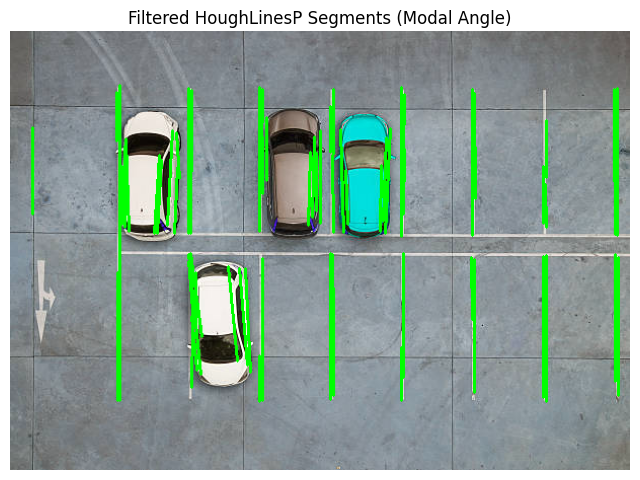

In [230]:
def step_3(linesP, image, horiz_thresh=45, angle_tolerance_deg=20):
    
    hough_lines = image.copy()
    
    horiz_center = np.pi / 2
    horiz_thresh = np.deg2rad(horiz_thresh)
    
    non_horiz = []
    
    if linesP is not None:
        for (x1, y1, x2, y2) in linesP[:,0]:
            rho, theta = line_to_rho_theta(x1, y1, x2, y2)
    
            # apply same horizontal filtering
            if abs(theta - horiz_center) >= horiz_thresh:
                # store full segment
                non_horiz.append((rho, theta, x1, y1, x2, y2))
    
    # Filter by modal angle (but keep original segments)
    filtered_lines, modal_angle_of_image = filter_by_modal_angle(non_horiz, angle_tolerance_deg=angle_tolerance_deg)
    
    # Draw filtered segments (NOT infinite lines)
    hough_lines = image.copy()
    
    for (rho, theta, x1, y1, x2, y2) in filtered_lines:
        cv2.line(hough_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(hough_lines)
    plt.title("Filtered HoughLinesP Segments (Modal Angle)")
    plt.axis("off")

    return filtered_lines, modal_angle_of_image

first_filtered_lines, modal_angle_of_image = step_3(linesP, image)
print(f"Modal Angle: {modal_angle_of_image}")

Not Rotating, -0.3614194330769974 degree angle


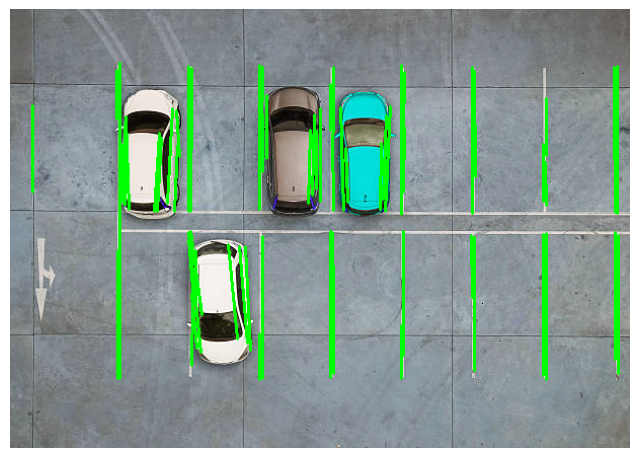

In [231]:
def rotate_image_nocrop(image, angle_deg, threshold_deg=10):
    """
    Rotate an image around its center without cropping.
    If |angle| < threshold_deg, no rotation is applied.
    Returns (rotated_image, affine_matrix M).
    """
    # Skip rotation if angle is small
    if abs(angle_deg) < threshold_deg:
        print(f"Not Rotating, {angle_deg} degree angle")
        M = None
        return image.copy(), M

    (h, w) = image.shape[:2]
    center = (w / 2, h / 2)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    # Compute new bounding box
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])

    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)

    # Adjust translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    # Rotate with reflection padding
    rotated = cv2.warpAffine(
        image, M, (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    return rotated, M

def rotate_points(segments, M):
    """
    Rotate a list of line segments using affine matrix M.
    segments = [(x1,y1,x2,y2), ...]
    Works even if M is the identity matrix (no rotation).
    """
    rotated = []
    if M is None:
        return segments
        
    for (x1, y1, x2, y2) in segments:
        p1 = M @ np.array([x1, y1, 1.0])
        p2 = M @ np.array([x2, y2, 1.0])

        rotated.append((
            int(round(p1[0])),
            int(round(p1[1])),
            int(round(p2[0])),
            int(round(p2[1]))
        ))

    return rotated

def recompute_rho_theta_for_rotated_segments(rotated_segments):
    updated = []
    for (x1, y1, x2, y2) in rotated_segments:
        rho, theta = line_to_rho_theta(x1, y1, x2, y2)
        updated.append((rho, theta, x1, y1, x2, y2))
    return updated

rotation_angle_deg = np.rad2deg(modal_angle_of_image)


rotated_image, M = rotate_image_nocrop(image, rotation_angle_deg, threshold_deg=2)

segments = [(x1,y1,x2,y2) for (_,_,x1,y1,x2,y2) in first_filtered_lines]


rotated_segments = rotate_points(segments, M)

output = rotated_image.copy()
for (x1, y1, x2, y2) in rotated_segments:
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.axis("off")
plt.show()


In [232]:
def merge_by_midpoint(segments, merge_radius=50):
    """
    Merge Hough lines purely by midpoint proximity.
    segments: [(rho, theta, x1, y1, x2, y2), ...]
    merge_radius: max distance between midpoints to consider them the same group
    """

    # Compute midpoints
    mids = []
    for (rho, theta, x1, y1, x2, y2) in segments:
        mx = (x1 + x2) * 0.5
        my = (y1 + y2) * 0.5
        mids.append((mx, my, x1, y1, x2, y2))

    # Clusters = list of lists
    clusters = []

    for item in mids:
        mx, my, x1, y1, x2, y2 = item
        placed = False

        # Check each existing cluster
        for c in clusters:
            # distance to cluster center (mean midpoint)
            cx = c['cx']
            cy = c['cy']
            if np.hypot(mx - cx, my - cy) < merge_radius:
                c['items'].append(item)
                # update cluster center
                xs = [i[0] for i in c['items']]
                ys = [i[1] for i in c['items']]
                c['cx'] = np.mean(xs)
                c['cy'] = np.mean(ys)
                placed = True
                break

        if not placed:
            clusters.append({
                'items': [item],
                'cx': mx,
                'cy': my
            })

    # Now merge each cluster into ONE line segment
    merged = []
    for c in clusters:
        xs = []
        ys = []
        for (_,_, x1,y1,x2,y2) in c['items']:
            xs += [x1, x2]
            ys += [y1, y2]

        # Take the two furthest-apart points in the cluster
        pts = np.column_stack([xs, ys])
        if len(pts) < 2:
            continue

        # find the longest pair
        dmax = 0
        p1, p2 = pts[0], pts[0]
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                d = np.hypot(pts[i,0]-pts[j,0], pts[i,1]-pts[j,1])
                if d > dmax:
                    dmax = d
                    p1, p2 = pts[i], pts[j]

        merged.append((int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])))

    return merged

    

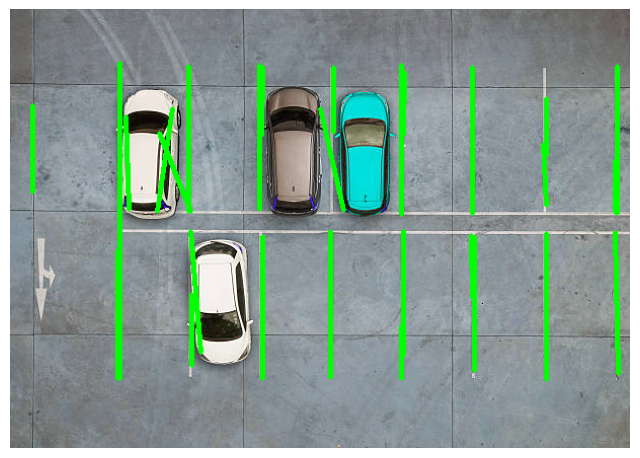

In [233]:
rotated_lines = []
for (x1, y1, x2, y2) in rotated_segments:
    new_rho, new_theta = line_to_rho_theta(x1, y1, x2, y2)
    rotated_lines.append((new_rho, new_theta, x1, y1, x2, y2))

merged = merge_by_midpoint(rotated_lines, merge_radius=30)

filtered_by_size = []
for x1, y1, x2, y2 in merged:
    length = np.hypot(x2 - x1, y2 - y1)
    if length >= 50:
        filtered_by_size.append((x1, y1, x2, y2))

out = rotated_image.copy()
for (x1, y1, x2, y2) in filtered_by_size:
    cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

plt.figure(figsize=(8, 8))
plt.imshow(out)
plt.axis("off")
plt.show()


-0.008620476112136332


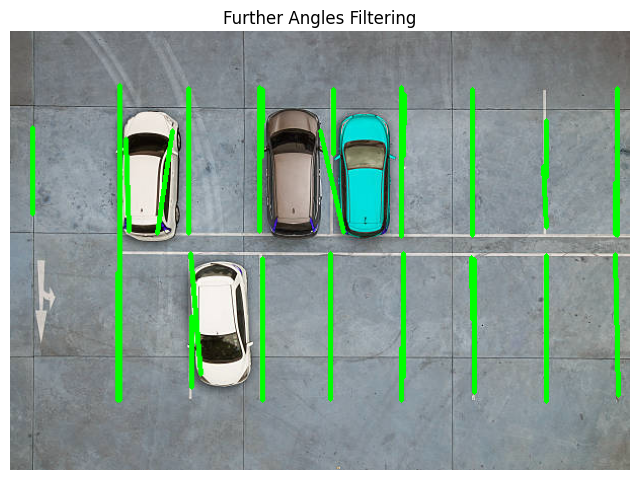

In [234]:
rotated_lines = []
for (x1, y1, x2, y2) in filtered_by_size:
    new_rho, new_theta = line_to_rho_theta(x1, y1, x2, y2)
    rotated_lines.append((new_rho, new_theta, x1, y1, x2, y2))


further_filtered_lines, modal_angle_of_image = filter_by_modal_angle(rotated_lines, angle_tolerance_deg=15)

out = rotated_image.copy()
for (rho, theta, x1, y1, x2, y2) in further_filtered_lines:
    cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

print(modal_angle_of_image)
plt.figure(figsize=(8, 8))
plt.imshow(out)
plt.title("Further Angles Filtering")
plt.axis("off")
plt.show()

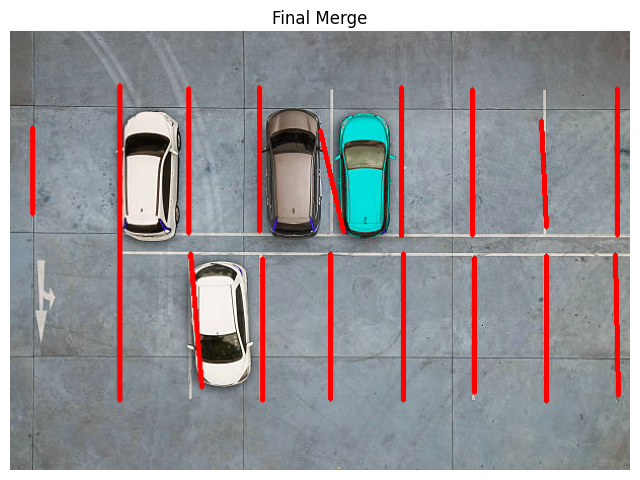

In [235]:
def line_length(x1, y1, x2, y2):
    return math.hypot(x2 - x1, y2 - y1)

def line_angle_deg(x1, y1, x2, y2):
    return math.degrees(math.atan2(y2 - y1, x2 - x1)) % 180

def nearly_parallel(l1, l2, max_angle_diff=5):
    a1 = line_angle_deg(*l1)
    a2 = line_angle_deg(*l2)
    return abs(a1 - a2) <= max_angle_diff

def merge_lines(l1, l2):
    """
    Merge two lines by taking the highest and lowest Y values from both lines,
    but using X coordinates projected from the longest line.
    """
    # unpack
    x1a, y1a, x2a, y2a = l1
    x1b, y1b, x2b, y2b = l2

    # determine longest line
    len_a = line_length(*l1)
    len_b = line_length(*l2)
    longest = (x1a, y1a, x2a, y2a) if len_a >= len_b else (x1b, y1b, x2b, y2b)

    # Y-extents from both lines
    ys = [y1a, y2a, y1b, y2b]
    y_low  = min(ys)
    y_high = max(ys)

    # project onto the longest line
    x1L, y1L, x2L, y2L = longest
    dx = x2L - x1L
    dy = y2L - y1L

    # avoid divide-by-zero for horizontal line
    if abs(dy) < 1e-9:
        # horizontal line: use x from midpoint of longest
        xm = (x1L + x2L) / 2
        return (xm, y_low, xm, y_high)

    # parametric projection: find X at chosen Y
    def x_at_y(Y):
        t = (Y - y1L) / dy
        return x1L + t * dx

    x_low  = x_at_y(y_low)
    x_high = x_at_y(y_high)

    return (x_low, y_low, x_high, y_high)


# ---------------- Corridor Geometry ---------------- #

def corridor_polygon(x1, y1, x2, y2, width=40, extend=5):
    dx = x2 - x1
    dy = y2 - y1
    L = math.hypot(dx, dy)
    if L < 1e-6:
        return None

    # unit direction
    ux = dx / L
    uy = dy / L

    # perpendicular (unit)
    px = -uy
    py =  ux

    # extend the segment slightly
    ex1 = x1 - ux * extend
    ey1 = y1 - uy * extend
    ex2 = x2 + ux * extend
    ey2 = y2 + uy * extend

    # corridor polygon (4 corners)
    return [
        (ex1 + px * width, ey1 + py * width),
        (ex2 + px * width, ey2 + py * width),
        (ex2 - px * width, ey2 - py * width),
        (ex1 - px * width, ey1 - py * width)
    ]

def point_in_poly(x, y, poly):
    """Ray casting algorithm for convex polygon point-in-poly test."""
    inside = False
    n = len(poly)
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        if ((y1 > y) != (y2 > y)):
            x_int = (x2 - x1) * (y - y1) / (y2 - y1 + 1e-9) + x1
            if x < x_int:
                inside = not inside
    return inside

def line_in_corridor(L1, L2, width=30):
    """Check if either endpoint of L2 lies inside corridor of L1."""
    x1, y1, x2, y2 = L1
    poly = corridor_polygon(x1, y1, x2, y2, width=width, extend=5)
    if poly is None:
        return False

    x3, y3, x4, y4 = L2
    return point_in_poly(x3, y3, poly) or point_in_poly(x4, y4, poly)

# ---------------- Final Merge ---------------- #

def final_merge_step(lines, x_thresh=40, y_tol=5):
    """
    lines: [(x1, y1, x2, y2), ...]
    Uses corridor-based merging logic.
    """

    # Sort longest first
    lines = sorted(lines, key=lambda L: line_length(*L), reverse=True)

    merged = []
    used = [False] * len(lines)

    for i in range(len(lines)):
        if used[i]:
            continue

        L1 = lines[i]
        best = L1  # keep updating this as merges occur

        for j in range(i + 1, len(lines)):
            if used[j]:
                continue

            L2 = lines[j]

            # corridor test against the *current* merged form of L1
            if not line_in_corridor(best, L2, width=x_thresh):
                continue

            # inside corridor → merge or delete
            if nearly_parallel(best, L2):
                best = merge_lines(best, L2)
                used[j] = True
            else:
                # not parallel → keep longer, drop shorter
                if line_length(*L2) < line_length(*best):
                    used[j] = True

        merged.append(best)

    return merged


final_lines = final_merge_step(
    [(x1, y1, x2, y2) for (_,_,x1,y1,x2,y2) in further_filtered_lines]
)

out = rotated_image.copy()
for x1, y1, x2, y2 in final_lines:
    cv2.line(out,
             (int(round(x1)), int(round(y1))),
             (int(round(x2)), int(round(y2))),
             (255, 0, 0), 4)

plt.figure(figsize=(8, 8))
plt.imshow(out)
plt.title("Final Merge")
plt.axis("off")
plt.show()


Modal length: 152.8
Kept lines: 16


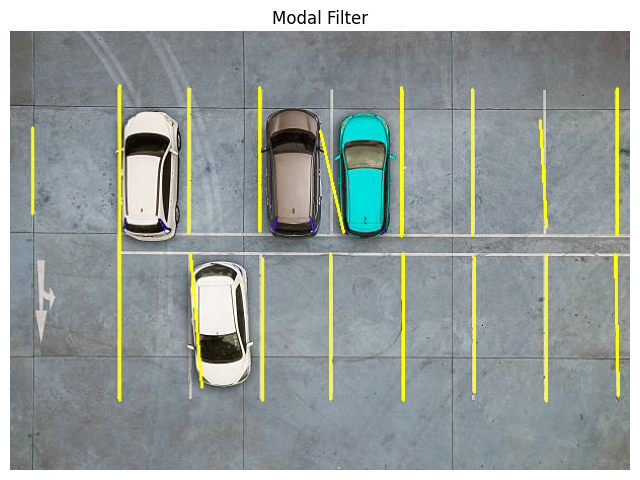

In [236]:
def filter_short_lines_by_modal_length(lines, bin_width=5):
    """
    1. Removes all lines shorter than half the AVERAGE length.
    2. Then finds the modal length and removes all lines shorter than half the MODAL length.

    lines can be:
      - (x1,y1,x2,y2)
      - (rho,theta,x1,y1,x2,y2)

    Returns: filtered_lines, modal_length
    """

    # Extract endpoints consistently
    endpoints = []
    for line in lines:
        if len(line) == 4:
            x1, y1, x2, y2 = line
        else:
            _, _, x1, y1, x2, y2 = line
        endpoints.append((x1, y1, x2, y2))

    # Compute lengths
    lengths = np.array([
        np.hypot(x2 - x1, y2 - y1) for (x1, y1, x2, y2) in endpoints
    ])

    if len(lengths) == 0:
        return [], 0

    #
    # --- Stage 1: Filter by average length ---
    #
    avg_length = np.mean(lengths)
    avg_threshold = 0.45 * avg_length

    filtered_stage1 = []
    endpoints_stage1 = []
    lengths_stage1 = []

    for i, line in enumerate(lines):
        if lengths[i] >= avg_threshold:
            filtered_stage1.append(line)
            endpoints_stage1.append(endpoints[i])
            lengths_stage1.append(lengths[i])

    if len(filtered_stage1) == 0:
        return [], 0

    lengths_stage1 = np.array(lengths_stage1)

    #
    # --- Stage 2: Compute modal length from remaining lines ---
    #
    hist, edges = np.histogram(lengths_stage1, bins=max(5, len(lengths_stage1)//10))
    modal_bin_index = np.argmax(hist)
    modal_length = (edges[modal_bin_index] + edges[modal_bin_index+1]) / 2.0

    modal_threshold = 0.33 * modal_length

    #
    # --- Final filtering ---
    #
    final_filtered = []
    for i, line in enumerate(filtered_stage1):
        if lengths_stage1[i] >= modal_threshold:
            final_filtered.append(line)

    return final_filtered, modal_length


filtered_lines, modal_length = filter_short_lines_by_modal_length(final_lines)
print("Modal length:", modal_length)
print("Kept lines:", len(filtered_lines))

out = rotated_image.copy()

for line in filtered_lines:
    if len(line) == 4:
        x1, y1, x2, y2 = line
    else:
        _, _, x1, y1, x2, y2 = line

    cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), (255,255,0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(out)
plt.title("Modal Filter")
plt.axis("off")
plt.show()

Rows detected: 1


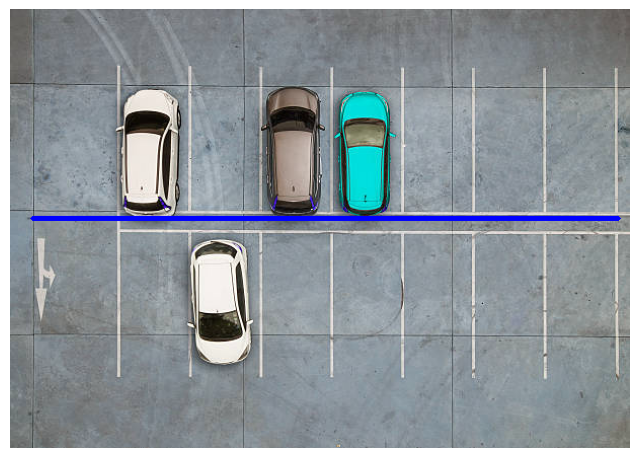

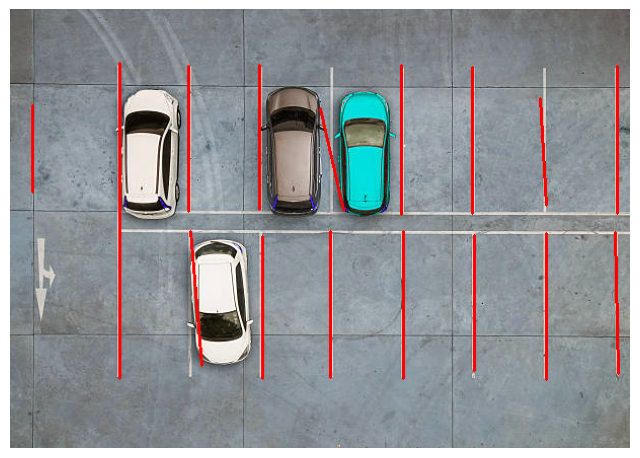

In [237]:
def cluster_rows_simple(lines, modal_length, jump_factor=0.6):
    """
    Pure-Python clustering of lines into parking rows based on midpoint-Y.
    
    - modal_length ≈ 2× stall length
    - jump_factor determines how far apart midpoints can be before starting a new row
    
    Returns:
        clusters: list of lists of (x1,y1,x2,y2)
        row_lines: representative row lines [(x1,y1,x2,y2), ...]
    """

    # Extract endpoints consistently
    segs = []
    mids = []   # store (mid_y, index)

    for i, line in enumerate(lines):
        if len(line) == 4:
            x1, y1, x2, y2 = line
        else:
            _, _, x1, y1, x2, y2 = line

        mid_y = (y1 + y2) / 2
        mids.append((mid_y, i))
        segs.append((x1, y1, x2, y2))

    if not segs:
        return [], []

    # Sort by midpoint Y
    mids.sort(key=lambda x: x[0])

    # Clustering threshold: ~ half a stall height
    threshold = modal_length * jump_factor

    clusters = []
    current_cluster = []
    prev_y = None

    for mid_y, idx in mids:
        if prev_y is None:
            current_cluster = [segs[idx]]
        else:
            if abs(mid_y - prev_y) > threshold:
                # Start new row
                clusters.append(current_cluster)
                current_cluster = [segs[idx]]
            else:
                # Same row
                current_cluster.append(segs[idx])

        prev_y = mid_y

    # Last cluster
    if current_cluster:
        clusters.append(current_cluster)

    # Build representative row lines
    row_lines = []
    for cl in clusters:
        xs = []
        ys = []
        for (x1, y1, x2, y2) in cl:
            xs.extend([x1, x2])
            ys.extend([y1, y2])

        x_min, x_max = min(xs), max(xs)
        y_mean = np.mean(ys)

        row_lines.append((int(x_min), int(y_mean), int(x_max), int(y_mean)))

    return clusters, row_lines

def draw_rows(image, row_lines, color=(0,0,255), thickness=3):
    out = image.copy()
    for (x1, y1, x2, y2) in row_lines:
        cv2.line(out, (x1, y1), (x2, y2), color, thickness)
    return out

def draw_cluster_lines(image, clusters):
    """
    Draws the individual line segments inside each row cluster,
    using different colors for each row.

    Colors:
      Row 0: Red
      Row 1: Blue
      Row 2: Yellow
      Row 3: White
      Row 4+: Green (fallback)
    """

    colors = [
        (255, 0, 0),     # Red
        (0, 0, 255),     # Blue
        (0, 255, 255),   # Yellow
        (255, 255, 255), # White
    ]
    fallback = (0, 255, 0)  # Green

    out = image.copy()

    for row_idx, row in enumerate(clusters):
        # choose color
        color = colors[row_idx] if row_idx < len(colors) else fallback

        # draw lines in this row
        for line in row:
            if len(line) == 4:
                x1, y1, x2, y2 = line
            else:
                _, _, x1, y1, x2, y2 = line

            cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

    return out

filtered_lines, modal_length = filter_short_lines_by_modal_length(final_lines)

clusters, row_lines = cluster_rows_simple(filtered_lines, modal_length)

print("Rows detected:", len(clusters))

out_rows = draw_rows(rotated_image, row_lines)

plt.figure(figsize=(8,8))
plt.imshow(out_rows)
plt.axis("off")
plt.show()

out_cluster_lines = draw_cluster_lines(rotated_image, clusters)
plt.figure(figsize=(8,8))
plt.imshow(out_cluster_lines)
plt.axis("off")
plt.show()

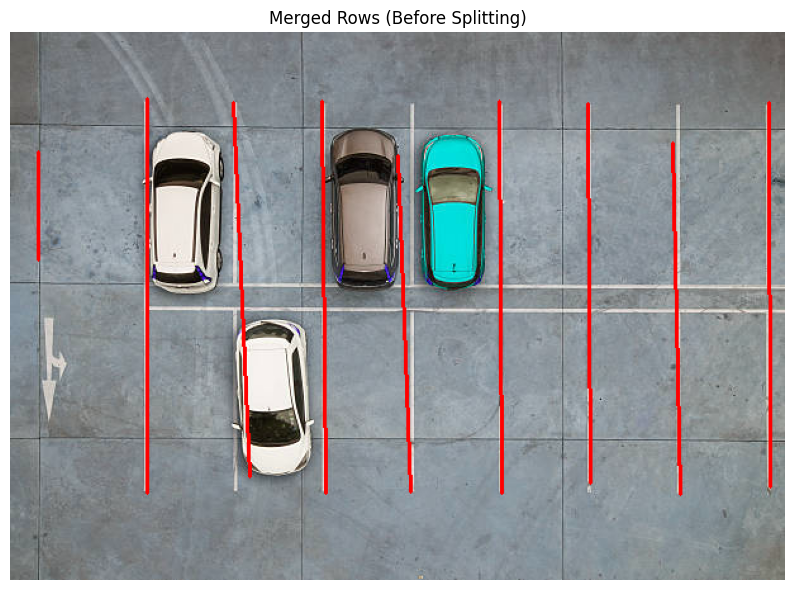

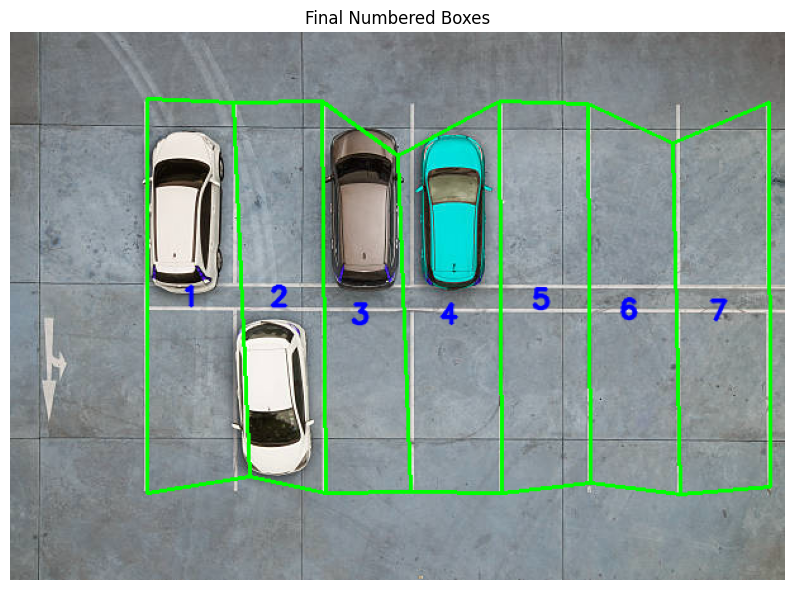

In [238]:
def merge_row_segments(row, gap_factor=0.2):
    """
    Merge fragmented line segments in a row into continuous stall-divider lines.
    Uses X-proximity only (correct for vertical divider lines).
    """

    segs = []
    for (x1, y1, x2, y2) in row:
        mean_x = (x1 + x2) / 2
        segs.append((mean_x, (x1, y1, x2, y2)))

    segs.sort(key=lambda v: v[0])

    lengths = [np.hypot(s[1][2]-s[1][0], s[1][3]-s[1][1]) for s in segs]
    median_len = np.median(lengths)

    max_dx = median_len * gap_factor

    merged = []
    current = None

    for mean_x, seg in segs:
        if current is None:
            current = seg
            continue

        cx1, cy1, cx2, cy2 = current
        cur_mean_x = (cx1 + cx2) / 2

        if abs(mean_x - cur_mean_x) < max_dx:
            # stitch vertically: find highest & lowest endpoints
            x1A, y1A, x2A, y2A = current
            x1B, y1B, x2B, y2B = seg

            xs = [x1A, x2A, x1B, x2B]
            ys = [y1A, y2A, y1B, y2B]

            top_idx = np.argmin(ys)
            bot_idx = np.argmax(ys)

            x_top,  y_top  = xs[top_idx], ys[top_idx]
            x_bot,  y_bot  = xs[bot_idx], ys[bot_idx]

            current = (x_top, y_top, x_bot, y_bot)

        else:
            merged.append(current)
            current = seg

    if current:
        merged.append(current)

    return merged



def order_line_endpoints(x1, y1, x2, y2):
    """Return endpoints ordered by vertical position (top-first)."""
    if y1 <= y2:
        return (x1, y1), (x2, y2)
    else:
        return (x2, y2), (x1, y1)


def build_boxes_connecting_lines(row):
    """
    Build stall boxes by connecting endpoints of adjacent divider lines.
    Produces quadrilateral boxes.
    """

    if len(row) < 2:
        return []

    # sort lines left→right by midpoint X
    row = sorted(row, key=lambda s: (s[0] + s[2]) / 2)

    boxes = []

    for i in range(len(row) - 1):
        (x1L, y1L, x2L, y2L) = row[i]
        (x1R, y1R, x2R, y2R) = row[i+1]

        TL, BL = order_line_endpoints(x1L, y1L, x2L, y2L)
        TR, BR = order_line_endpoints(x1R, y1R, x2R, y2R)

        boxes.append([TL, TR, BR, BL])

    return boxes


def draw_quadrilateral_boxes_with_numbers(image, boxes, 
                                          box_color=(0,255,0), 
                                          text_color=(0,0,255),
                                          thickness=2):
    """Draw quadrilateral boxes and label each with a number."""
    out = image.copy()

    for i, box in enumerate(boxes):

        pts = np.array(box, dtype=np.int32)
        cv2.polylines(out, [pts], True, box_color, thickness)

        # centroid
        cx = int(np.mean([p[0] for p in box]))
        cy = int(np.mean([p[1] for p in box]))

        cv2.putText(
            out,
            str(i+1),
            (cx - 10, cy + 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            text_color,
            2,
            cv2.LINE_AA,
        )

    return out


def split_line_in_half_vertical(x1, y1, x2, y2):
    """Split a line into upper and lower halves based on vertical position."""
    if y1 < y2:
        top = (x1, y1)
        bottom = (x2, y2)
    else:
        top = (x2, y2)
        bottom = (x1, y1)

    mx = (top[0] + bottom[0]) / 2
    my = (top[1] + bottom[1]) / 2
    mid = (mx, my)

    upper = (top[0], top[1], mid[0], mid[1])
    lower = (mid[0], mid[1], bottom[0], bottom[1])

    return upper, lower


def split_double_row_if_needed(row, y_threshold=40, long_factor=1.9):
    """
    Splits a merged cluster into two rows if there is a vertical gap.
    Long connector lines are split into upper/lower lines.
    """

    mids = []
    lengths = []

    for (x1, y1, x2, y2) in row:
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        mids.append((mx, my))
        lengths.append(np.hypot(x2 - x1, y2 - y1))

    ys = np.array([my for (_, my) in mids])
    avg_len = np.mean(lengths)

    if np.max(ys) - np.min(ys) < y_threshold:
        return [row]

    sorted_idx = np.argsort(ys)
    sorted_y = ys[sorted_idx]
    diffs = np.diff(sorted_y)

    split_idx = np.argmax(diffs)

    if diffs[split_idx] < 0.5 * np.median(diffs):
        return [row]

    split_y = 0.5 * (sorted_y[split_idx] + sorted_y[split_idx + 1])

    upper_row, lower_row = [], []

    for (line, length, (mx, my)) in zip(row, lengths, mids):
        x1, y1, x2, y2 = line

        if length >= long_factor * avg_len:
            up_seg, down_seg = split_line_in_half_vertical(x1, y1, x2, y2)

            uy = (up_seg[1] + up_seg[3]) / 2
            ly = (down_seg[1] + down_seg[3]) / 2

            if uy < ly:
                upper_row.append(up_seg)
                lower_row.append(down_seg)
            else:
                upper_row.append(down_seg)
                lower_row.append(up_seg)
        else:
            if my < split_y:
                upper_row.append(line)
            else:
                lower_row.append(line)

    return [upper_row, lower_row]


def draw_final_rows(image, final_rows):
    """Draw each final row in a different color for debugging."""
    colors = [
        (255,0,0), (0,0,255), (0,255,255),
        (255,255,255), (0,0,0)
    ]
    fallback = (0,255,0)

    out = image.copy()

    for i, row in enumerate(final_rows):
        color = colors[i] if i < len(colors) else fallback
        for (x1,y1,x2,y2) in row:
            cv2.line(out, (int(x1),int(y1)), (int(x2),int(y2)), color, 2)

    return out

final_row_sets = []

for row in clusters:

    # 1. merge first
    merged_row = merge_row_segments(row)

    # 2. then split into one or two rows
    split_rows = split_double_row_if_needed(merged_row)

    # add 1 row or 2 rows to final list
    final_row_sets.extend(split_rows)

# debug draw of merged rows BEFORE splitting (optional)
debug_merged = draw_final_rows(rotated_image, [merge_row_segments(r) for r in clusters])

plt.figure(figsize=(10,10))
plt.imshow(debug_merged)
plt.title("Merged Rows (Before Splitting)")
plt.axis("off")
plt.show()

# Build boxes from rows
all_boxes = []

for row in final_row_sets:
    merged_row = merge_row_segments(row)
    row_boxes = build_boxes_connecting_lines(merged_row)
    all_boxes.extend(row_boxes)

# draw boxes with numbers
out = draw_quadrilateral_boxes_with_numbers(rotated_image, all_boxes)

plt.figure(figsize=(10,10))
plt.imshow(out)
plt.title("Final Numbered Boxes")
plt.axis("off")
plt.show()


In [239]:
def compute_box_width(box):
    (xTL, yTL), (xTR, yTR), (xBR, yBR), (xBL, yBL) = box

    # Midpoints of left and right divider lines
    MLx = (xTL + xBL) / 2
    MLy = (yTL + yBL) / 2

    MRx = (xTR + xBR) / 2
    MRy = (yTR + yBR) / 2

    # Straight-line distance between midpoint of left and right divider
    return np.hypot(MRx - MLx, MRy - MLy)



def modal_box_spacing(boxes, bins=20):
    widths = np.array([compute_box_width(b) for b in boxes])

    hist, edges = np.histogram(widths, bins=bins)
    idx = np.argmax(hist)

    modal_width = (edges[idx] + edges[idx+1]) / 2

    return modal_width, widths


# -----------------------------------
# Compute modal spacing
# -----------------------------------
modal_width, all_widths = modal_box_spacing(all_boxes)

print("Modal Stall Width: ", modal_width)

Modal Stall Width:  65.5707540391358


In [240]:
def filter_boxes_by_width(boxes, modal_width, tolerance=0.05):
    """
    Removes boxes that exceed modal width by more than tolerance (default 5%).
    
    boxes: list of quadrilateral boxes
    modal_width: modal stall spacing (pixels)
    
    Returns:
        filtered_boxes, removed_boxes
    """
    max_allowed = modal_width * (1 + tolerance)

    filtered = []
    removed = []

    for box in boxes:
        w = compute_box_width(box)
        if w <= max_allowed:
            filtered.append(box)
        else:
            removed.append(box)

    return filtered, removed

Total boxes: 7
Kept: 3
Removed: 4


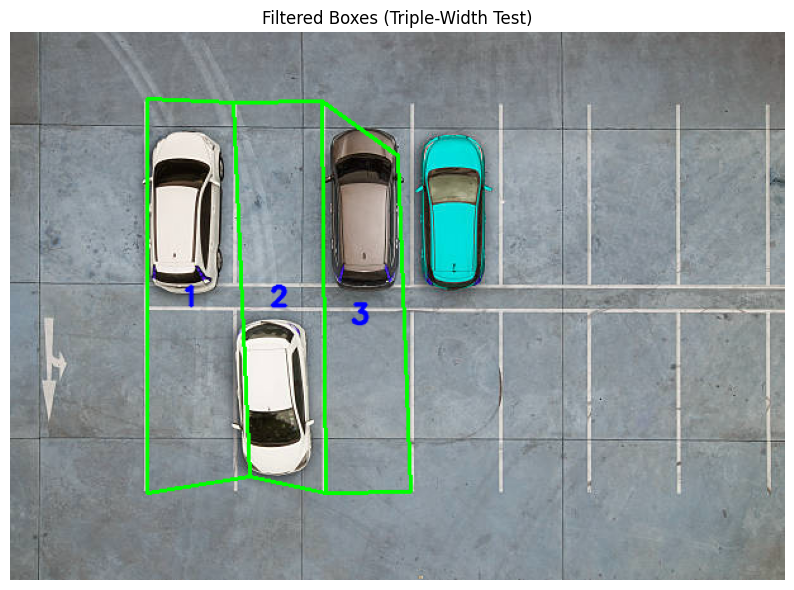

In [259]:
def compute_top_width(box):
    TL, TR, _, _ = box
    return np.hypot(TR[0] - TL[0], TR[1] - TL[1])

def compute_bottom_width(box):
    _, _, BR, BL = box
    return np.hypot(BR[0] - BL[0], BR[1] - BL[1])

def compute_mid_width(box):
    TL, TR, BR, BL = box
    midL = ((TL[0] + BL[0]) / 2, (TL[1] + BL[1]) / 2)
    midR = ((TR[0] + BR[0]) / 2, (TR[1] + BR[1]) / 2)
    return np.hypot(midR[0] - midL[0], midR[1] - midL[1])


def filter_boxes_by_triple_width(boxes, modal_width, tolerance=0.06):
    """
    Keep a box if ANY of the following are within ±tolerance of modal width:
      • top width
      • mid width
      • bottom width
    
    Reject only if ALL 3 differ by more than tolerance.
    """
    filtered = []
    removed = []

    low = modal_width * (1 - tolerance)
    high = modal_width * (1 + tolerance)

    for box in boxes:

        top_w = compute_top_width(box)
        mid_w = compute_mid_width(box)
        bot_w = compute_bottom_width(box)

        valid_top = (low <= top_w <= high)
        valid_mid = (low <= mid_w <= high)
        valid_bot = (low <= bot_w <= high)

        # keep if ANY measurement matches expected stall width
        if valid_top or valid_mid or valid_bot:
            filtered.append(box)
        else:
            removed.append(box)

    return filtered, removed

filtered_boxes, removed_boxes = filter_boxes_by_triple_width(
    all_boxes,
    modal_width,
    tolerance=0.05
)

print("Total boxes:", len(all_boxes))
print("Kept:", len(filtered_boxes))
print("Removed:", len(removed_boxes))

out_filtered = draw_quadrilateral_boxes_with_numbers(rotated_image, filtered_boxes)

plt.figure(figsize=(10,10))
plt.imshow(out_filtered)
plt.title("Filtered Boxes (Triple-Width Test)")
plt.axis("off")
plt.show()

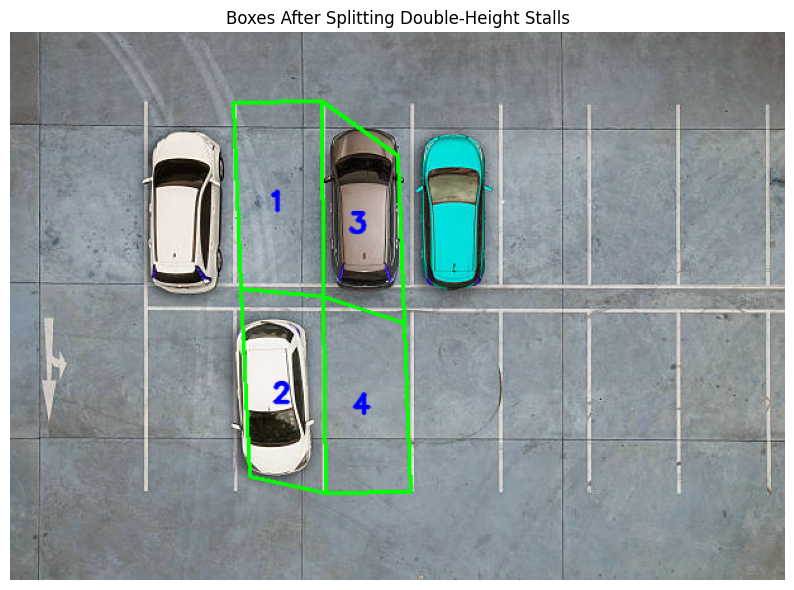

In [242]:
def compute_box_height(box):
    (TL, TR, BR, BL) = box
    left_h  = np.hypot(TL[0]-BL[0], TL[1]-BL[1])
    right_h = np.hypot(TR[0]-BR[0], TR[1]-BR[1])
    return 0.5 * (left_h + right_h)

def split_box_if_needed(box, modal_width):
    """
    Splits a box into two equal-height boxes if:
        height > 2 * modal_width
    
    Returns: list of 1 (unsplit) or 2 (split) boxes.
    """

    height = compute_box_height(box)

    # Condition for splitting: height is roughly 2 spaces tall
    if height <= 2 * modal_width:
        return [box]  # no split

    # --- Split into exactly 2 boxes vertically (height direction) ---
    (TL, TR, BR, BL) = box

    TL = np.array(TL, float)
    TR = np.array(TR, float)
    BR = np.array(BR, float)
    BL = np.array(BL, float)

    # Midpoints along the height direction
    mid_left  = (TL + BL) / 2.0
    mid_right = (TR + BR) / 2.0

    # Top box
    box1 = [
        tuple(TL),
        tuple(TR),
        tuple(mid_right),
        tuple(mid_left)
    ]

    # Bottom box
    box2 = [
        tuple(mid_left),
        tuple(mid_right),
        tuple(BR),
        tuple(BL)
    ]

    return [box1, box2]

def split_double_height_boxes(boxes, modal_width):
    out = []
    for box in boxes:
        out.extend(split_box_if_needed(box, modal_width))
    return out

split_boxes = split_double_height_boxes(filtered_boxes, modal_width)

out_split = draw_quadrilateral_boxes_with_numbers(rotated_image, split_boxes)

plt.figure(figsize=(10,10))
plt.imshow(out_split)
plt.title("Boxes After Splitting Double-Height Stalls")
plt.axis("off")
plt.show()
